In [1]:
import os, json, pdb, copy
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from kdutils.macro2 import *
from lib.syn001.linear import composit_equal

In [3]:
method = 'ricso2'
instruments = 'rbb'
task_id = '113001'
period = 5
corr = 7.0

In [4]:
def load_data2(method, instruments, task_id, period):
    base_dirs = os.path.join(base_path, method, instruments, 'temp', 'model',
                             str(task_id), str(period), 'rl', 'data')

    train_data = pd.read_feather(os.path.join(base_dirs, "train_data.feather"))

    val_data = pd.read_feather(os.path.join(base_dirs, "val_data.feather"))

    test_data = pd.read_feather(os.path.join(base_dirs, "test_data.feather"))
    
    return train_data, val_data, test_data

In [5]:
train_data, val_data, test_data = load_data2(method=method,
                                                 instruments=instruments,
                                                 task_id=task_id,
                                                 period=period)

## 
#test_data = pd.concat([val_data,test_data],axis=0).sort_values(by=['trade_time','code'])

In [6]:
csv_file = 'records/ricso2/rbb/temp/model/113001/5/rl/blend/corr/{0}.csv'.format(corr)
corr_data = pd.read_csv(csv_file, index_col=0)
train_data1 = train_data[['trade_time', 'code'] +
                                 corr_data['expression'].to_list()]
val_data1 = val_data[['trade_time', 'code'] +
                             corr_data['expression'].to_list()]
test_data1 = test_data[['trade_time', 'code'] +
                               corr_data['expression'].to_list()]


In [7]:
data1, evaluate1 = composit_equal(data=test_data, 
                               selected_features=corr_data['expression'].to_list(), 
                               roll_win=15, 
                               period=period, 
                               scale_method='raw',
                               expression='corr_{0}'.format(corr))

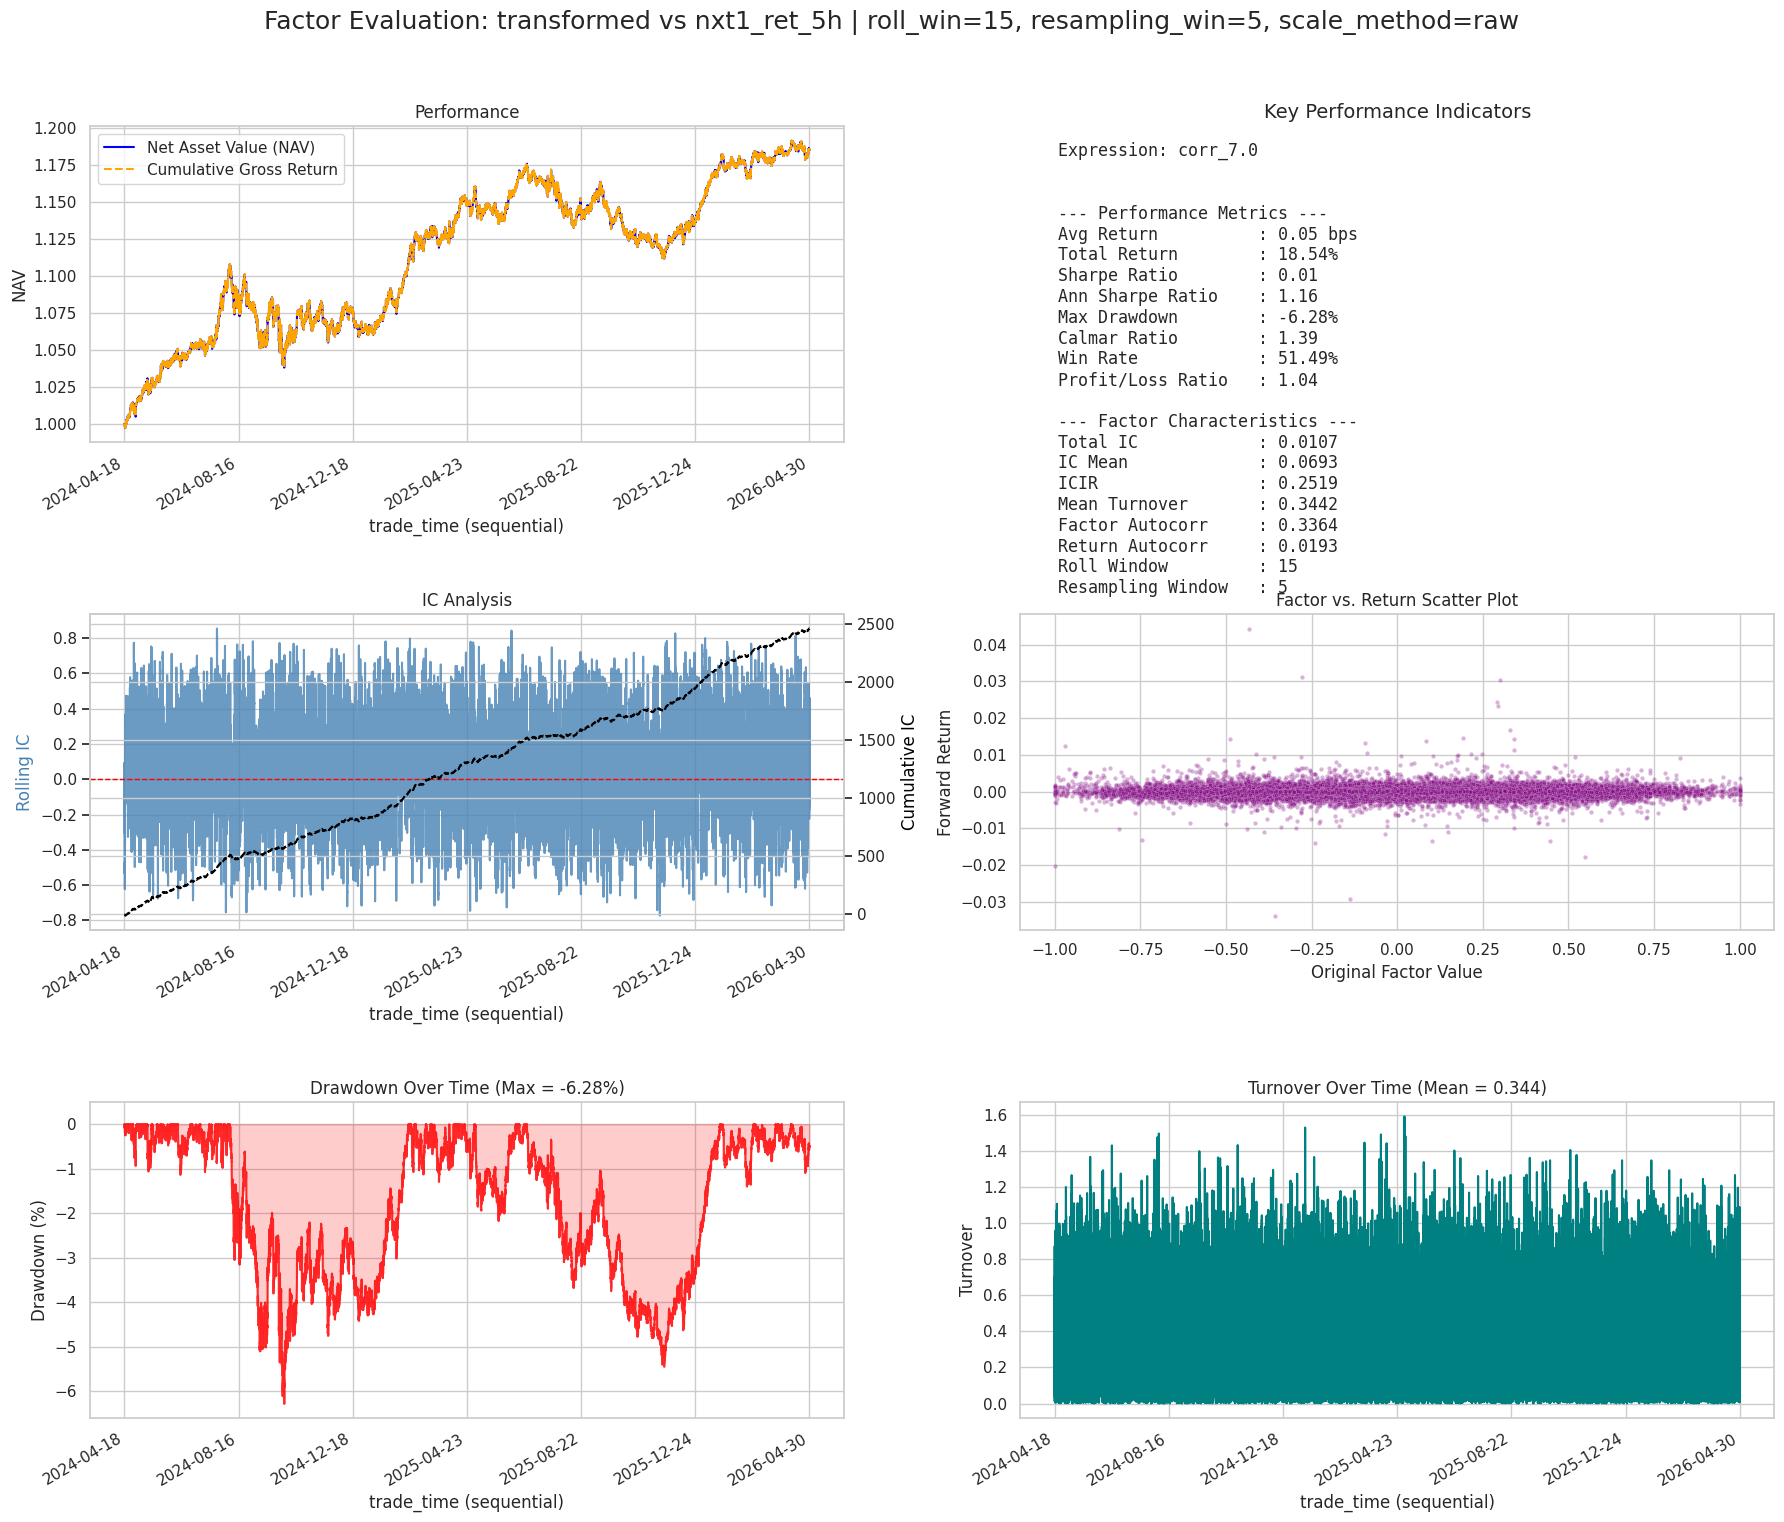

In [8]:
evaluate1.plot_results()